In [1]:
import py_wake 

# setup site, wind turbines and wind farm model with the corresponding wake models
import numpy as np
import ipywidgets 
from ipywidgets import interact
from ipywidgets import IntSlider
import matplotlib.pyplot as plt

from py_wake.flow_map import HorizontalGrid
from py_wake.examples.data.iea37._iea37 import IEA37Site, IEA37_WindTurbines
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.flow_map import XYGrid

In [10]:
site = IEA37Site(16)
x, y = [0, 600, 1200], [0, 0, 0]
windTurbines = IEA37_WindTurbines()
h = windTurbines.hub_height(0)
print(h)
wfm = Bastankhah_PorteAgel_2014(site, windTurbines, k=0.0324555, deflectionModel=JimenezWakeDeflection())

110.0


In [13]:
# define function that plots the flow field and AEP history of 3 wind turbines
def plot_flow_field(WT0, WT1, TILT):

    ax1 = plt.figure(figsize=(12,4)).gca()
   
    sim_res = wfm(x, y, yaw=np.reshape([WT0,WT1,0],(3,1,1)), wd=270, ws=10, tilt=TILT)
    sim_res.flow_map(HorizontalGrid(x = np.linspace(0,1400,200), y=np.linspace(-200,200,50))).plot_wake_map(ax=ax1)
    ax1.set_xlim([-200,1400])

# def get_flow_map(model=None, grid=XYGrid(x=np.linspace(-200, 500, 200), y=np.linspace(-200, 200, 200), h=70),
#                  turbulenceModel=CrespoHernandez()):
#     blockage_deficitModel = [None, model][isinstance(model, BlockageDeficitModel)]
#     wake_deficitModel = [NoWakeDeficit(), model][isinstance(model, WakeDeficitModel)]
#     wfm = All2AllIterative(UniformSite(), V80(), wake_deficitModel=wake_deficitModel, blockage_deficitModel=blockage_deficitModel,
#                            turbulenceModel=turbulenceModel)
#     return wfm(x=[0], y=[0], wd=270, ws=10, yaw=0).flow_map(grid)
    
def plot_flow_profile(wfm,WT0, WT1, TILT):
    ax2 = plt.figure(figsize=(6,4)).gca()
    grid = XYGrid(x=300, y=np.linspace(-200,200,300))
    # sim_res = wfm(x, y, yaw=np.reshape([WT0,WT1,0],(3,1,1)), wd=270, ws=10, tilt=TILT)
    fm = wfm(x, y, yaw=np.reshape([WT0,WT1,0],(3,1,1)), wd=270, ws=10, tilt=TILT).flow_map(grid)
    ax2.plot(fm.y, 10-fm.WS_eff.squeeze())

def plot_particle_vel(wfm, WT0, WT1, TILT, xpart,ypart):
    ax2 = plt.gca()
    grid = XYGrid(x=xpart, y=ypart, h=h)
    fm = wfm(x, y, yaw=np.reshape([WT0,WT1,0],(3,1,1)), wd=270, ws=10, tilt=TILT).flow_map(grid)
    ax2.plot(fm.y, 10-fm.WS_eff.squeeze(),'*r')
   

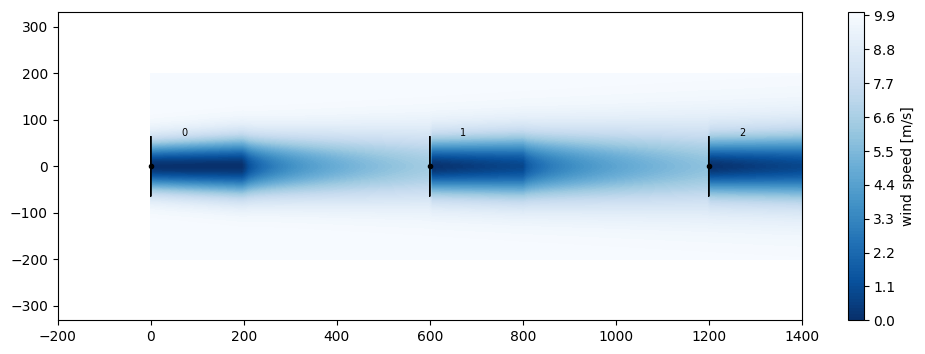

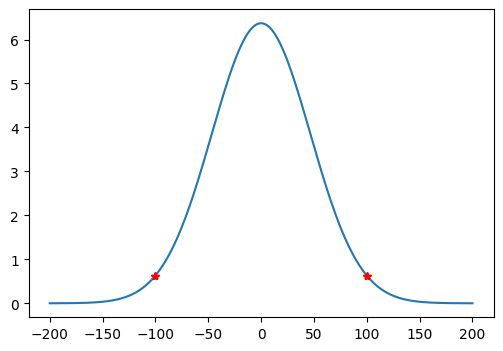

In [15]:
# Run the plot_flow_field_and_aep function when moving the sliders
plot_flow_field(0,0,0)

plot_flow_profile(wfm,0,0,0)

plot_particle_vel(wfm,0,0,0,np.array([300, 300]),np.array([-100, 100]))
plt.show()